In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


### Diagnosing Bias and Variance in Regression Trees

### Context & Goal

You are analysing predictive stability in car fuel efficiency models. Your task is to **investigate the bias–variance behaviour** of a regression tree trained on the *Auto MPG* dataset.
You must decide whether your model is **underfitting (high bias)** or **overfitting (high variance)** by comparing its **training** and **cross-validated** errors — without relying on pre-provided variables or code stubs.

### Learning Targets

* Implement the full modelling pipeline: loading, preprocessing, splitting, training, evaluation.
* Derive training and validation errors manually and interpret them statistically.
* Identify whether model bias or variance dominates and justify your conclusion quantitatively.
* Reason about how hyperparameters like `max_depth` and `min_samples_leaf` influence model stability.

### Dataset

**Name:** California Housing Dataset <br>
**Source:** [`sklearn.datasets.fetch_california_housing`](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)<br>
**Description:** Each row represents a California census block group, with demographic and environmental features such as:<br>

* median income<br>
* average rooms per household<br>
* average bedrooms per household<br>
* population<br>
* housing median age<br>
* latitude and longitude<br>

**Target Variable:** `MedHouseVal` — median house value (in $100,000s).<br>

### Task Instructions

1. **Data Preparation**

   * Load the dataset using `fetch_california_housing()`.
   * Convert it into a Pandas DataFrame for convenience.
   * Optionally scale or log-transform the target variable to stabilise variance.
   * Split the data into predictors `X` and target `y`.

In [ ]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="MedHouseVal")

In [ ]:
y_log = np.log(y.copy())

In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [21]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [22]:
from sklearn.base import BaseEstimator, TransformerMixin


class LatLonEncoder(BaseEstimator, TransformerMixin):
	"""
	A transformer that encodes latitude and longitude coordinates using trigonometric functions.

	This transformer converts latitude and longitude coordinates into sine and cosine
	components to handle the cyclical nature of geographic coordinates, which improves
	model performance for location-based features.

	Parameters
	----------
	lat_col : str, default="latitude"
		Name of the latitude column in the DataFrame
	lon_col : str, default="longitude"
		Name of the longitude column in the DataFrame
	drop_original : bool, default=True
		Whether to drop the original latitude and longitude columns after transformation

	Attributes
	----------
	lat_col : str
		Name of the latitude column
	lon_col : str
		Name of the longitude column
	drop_original : bool
		Whether to drop original columns after transformation
	"""

	def __init__(
		self,
		lat_col: str = "latitude",
		lon_col: str = "longitude",
		drop_original: bool = True,
	):
		self.lat_col = lat_col
		self.lon_col = lon_col
		self.drop_original = drop_original

	def fit(self, X: pd.DataFrame, y=None) -> "LatLonEncoder":
		"""
		Fit the transformer (no operation needed as this is a stateless transformer).

		Parameters
		----------
		X : pd.DataFrame
			Input DataFrame containing latitude and longitude columns
		y : array-like, default=None
			Target values (ignored)

		Returns
		-------
		self : LatLonEncoder
			Returns the transformer instance
		"""
		return self

	def transform(self, X: pd.DataFrame) -> pd.DataFrame:
		"""
		Transform latitude and longitude coordinates into trigonometric features.

		Parameters
		----------
		X : pd.DataFrame
			Input DataFrame containing latitude and longitude columns

		Returns
		-------
		X_transformed : pd.DataFrame
			DataFrame with original features plus trigonometric latitude/longitude features

		Raises
		------
		ValueError
			If the specified latitude or longitude columns are not found in the DataFrame
		"""
		if not {self.lat_col, self.lon_col}.issubset(X.columns):
			raise ValueError(
				f"Columns '{self.lat_col}' and '{self.lon_col}' must exist in input DataFrame."
			)

		# Convert to radians
		lat_rad = np.radians(X[self.lat_col])
		lon_rad = np.radians(X[self.lon_col])

		# Create transformed features
		X_transformed = X.copy()
		X_transformed[f"{self.lat_col}_sin"] = np.sin(lat_rad)
		X_transformed[f"{self.lat_col}_cos"] = np.cos(lat_rad)
		X_transformed[f"{self.lon_col}_sin"] = np.sin(lon_rad)
		X_transformed[f"{self.lon_col}_cos"] = np.cos(lon_rad)

		if self.drop_original:
			X_transformed = X_transformed.drop(columns=[self.lat_col, self.lon_col])

		return X_transformed

2. **Construct and Split**

   * Decide on an appropriate random seed.
   * Split your dataset into a **training** and **testing** set (choose your proportions thoughtfully and justify them).

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
	X, y_log, test_size=0.2, random_state=42
)

In [23]:
latlon = LatLonEncoder(lat_col="Latitude", lon_col="Longitude", drop_original=True)

X_train_transformed = latlon.fit_transform(X_train)
X_test_transformed = latlon.transform(X_test)

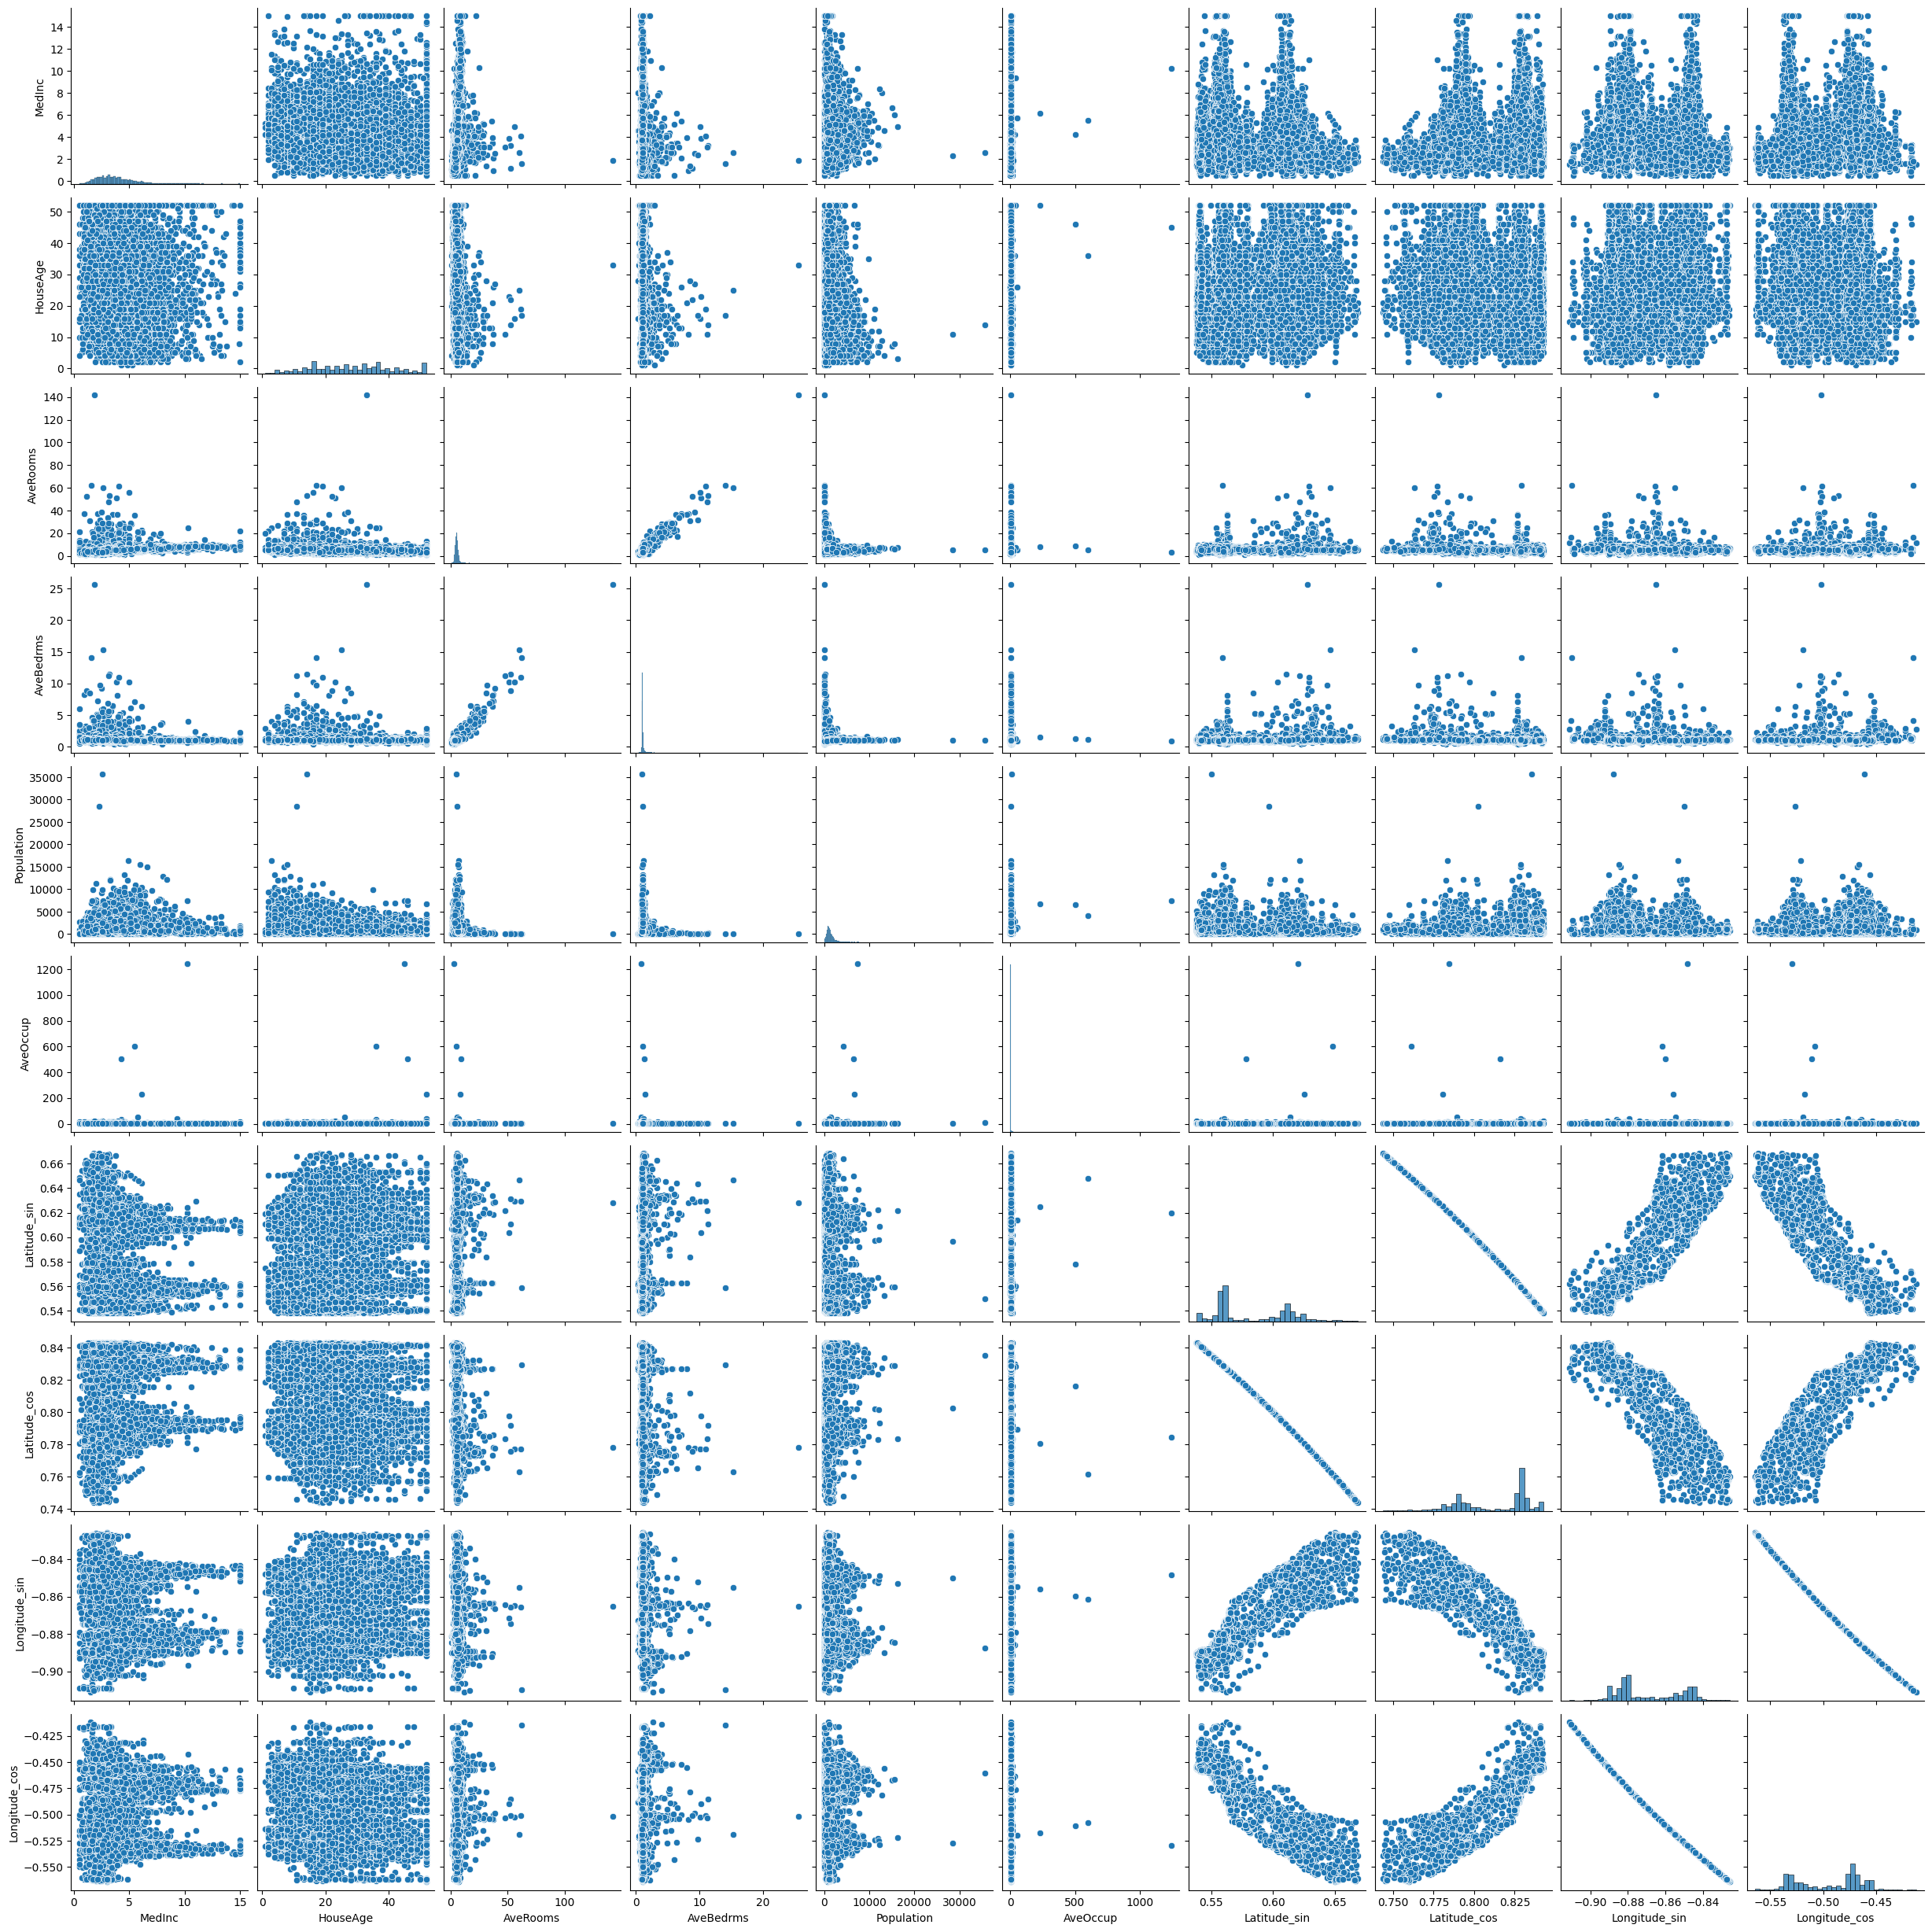

In [28]:
sns.pairplot(X_train_transformed)
plt.show()

In [24]:
X_train_transformed

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude_sin,Latitude_cos,Longitude_sin,Longitude_cos
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,0.540387,0.841416,-0.890769,-0.454457
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,0.555860,0.831276,-0.881633,-0.471935
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,0.568705,0.822541,-0.861806,-0.507238
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,0.540093,0.841605,-0.890133,-0.455700
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,0.598744,0.800940,-0.867765,-0.496974
...,...,...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,0.556006,0.831179,-0.883275,-0.468855
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,0.559482,0.828842,-0.887574,-0.460665
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,0.559627,0.828745,-0.879815,-0.475317
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,0.609869,0.792503,-0.848418,-0.529327


3. **Train a Decision Tree Regressor**

   * Select your own values for `max_depth` and `min_samples_leaf` that you expect might reveal bias or variance behaviour.
   * Fit the model to your training set.

In [6]:
from sklearn.tree import DecisionTreeRegressor

# Create an overfitted model with extreme flexibility
dtr_biased = DecisionTreeRegressor(
	max_depth=None,  # Allow unlimited depth
	min_samples_leaf=1,  # Allow single samples in leaves
	min_samples_split=2,  # Split with just 2 samples
	max_features=None,  # Use all features for splits
	random_state=42,
)

dtr_biased.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


4. **Assess Model Performance**

   * Compute **training RMSE** manually.
   * Perform **k-fold cross-validation** (k = 5 or 10) and compute **cross-validated RMSE**.
   * Compare the magnitude and variability of both metrics.

In [7]:
from sklearn.metrics import (
	r2_score,
	root_mean_squared_error as RMSE,
)

# First, let's compute TRAINING error (on the data the model learned from)
y_train_pred = dtr_biased.predict(X_train)
train_rmse = RMSE(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Then, compute TEST error (on unseen data)
y_test_pred = dtr_biased.predict(X_test)
test_rmse = RMSE(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"RMSE - Biased: {train_rmse:.4f}")
print(f"R² - Biased: {train_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²: {test_r2:.4f}")

RMSE - Biased: 0.0000
R² - Biased: 1.0000
RMSE: 0.3366
R²: 0.6509


In [8]:
# Perform k-fold cross-validation to assess generalization
from sklearn.model_selection import cross_val_score

# Use 5-fold CV and negative RMSE (sklearn convention)
cv_scores = cross_val_score(
	dtr_biased, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error"
)

# Convert back to positive RMSE
cv_rmse_scores = -cv_scores
cv_mean_rmse = cv_rmse_scores.mean()
cv_std_rmse = cv_rmse_scores.std()

print(f"Mean CV RMSE: {cv_mean_rmse:.4f}")
print(f"Std Dev: {cv_std_rmse:.4f}")
print(f"Individual fold RMSEs: {cv_rmse_scores}")
print(f"Notice: CV RMSE ({cv_mean_rmse:.4f}) >> Training RMSE ({train_rmse:.4f})")

Mean CV RMSE: 0.3427
Std Dev: 0.0053
Individual fold RMSEs: [0.35144364 0.34155737 0.33936687 0.34497765 0.33596785]
Notice: CV RMSE (0.3427) >> Training RMSE (0.0000)


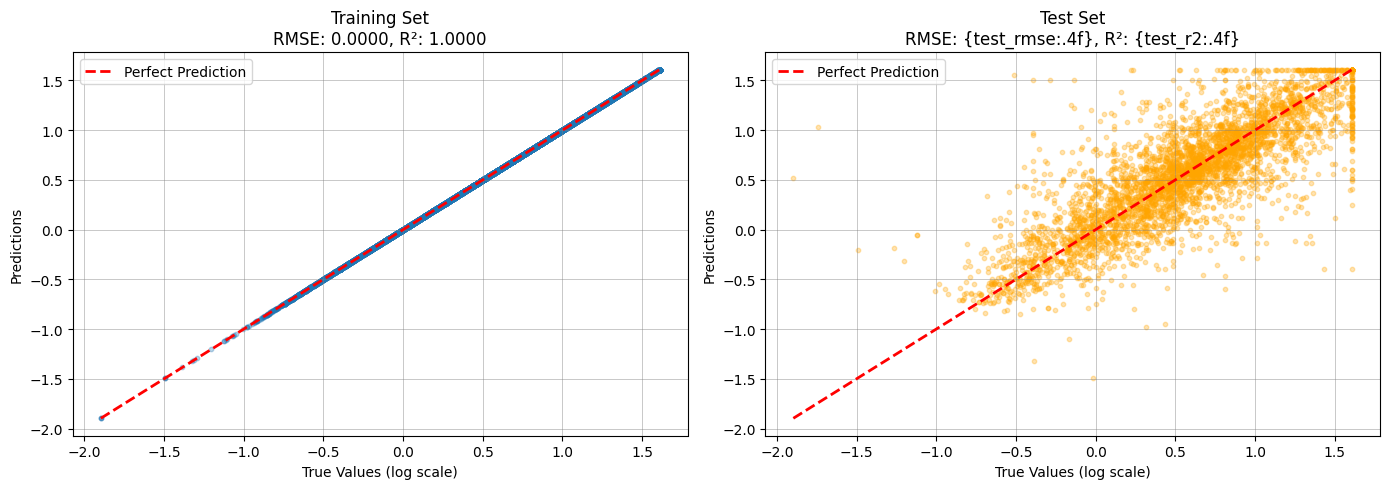

In [ ]:
# Visualize the overfitting with actual vs predicted plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training data predictions
axes[0].scatter(y_train, y_train_pred, alpha=0.3, s=10)
axes[0].plot(
	[y_train.min(), y_train.max()],
	[y_train.min(), y_train.max()],
	"r--",
	lw=2,
	label="Perfect Prediction",
)
axes[0].set(
	title=f"Training Set\nRMSE: {train_rmse:.4f}, R²: {train_r2:.4f}",
	xlabel="True Values (log scale)",
	ylabel="Predictions",
)
axes[0].legend()
axes[0].grid(True, alpha=0.6, linewidth=0.5, color="grey")

# Test data predictions
axes[1].scatter(y_test, y_test_pred, alpha=0.3, s=10, color="orange")
axes[1].plot(
	[y_test.min(), y_test.max()],
	[y_test.min(), y_test.max()],
	"r--",
	lw=2,
	label="Perfect Prediction",
)
axes[1].set(
	title="Test Set\nRMSE: {test_rmse:.4f}, R²: {test_r2:.4f}",
	xlabel="True Values (log scale)",
	ylabel="Predictions",
)
axes[1].legend()
axes[1].grid(True, alpha=0.6, linewidth=0.5, color="grey")

plt.tight_layout()
plt.show()

In [10]:
print(f"Max depth reached: {dtr_biased.get_depth()}")
print(f"Number of leaves: {dtr_biased.get_n_leaves()}")
print(f"Total nodes: {dtr_biased.tree_.node_count}")
print(f"- With {dtr_biased.get_n_leaves()} leaves and {len(X_train)} training samples,")
print("the tree can create extremely specific rules for small data subsets")
print(f"- Depth of {dtr_biased.get_depth()} allows very complex decision boundaries")
print("- min_samples_leaf=1 means leaves can contain just 1 sample")
print("- The model memorizes noise and outliers instead of learning patterns")

Max depth reached: 41
Number of leaves: 15874
Total nodes: 31747
- With 15874 leaves and 16512 training samples,
the tree can create extremely specific rules for small data subsets
- Depth of 41 allows very complex decision boundaries
- min_samples_leaf=1 means leaves can contain just 1 sample
- The model memorizes noise and outliers instead of learning patterns


In [11]:
print("\n" + "=" * 60)
print("BALANCED MODEL FOR COMPARISON")
print("=" * 60 + "\n")

dtr_balanced = DecisionTreeRegressor(
	max_depth=5,  # Limit depth to prevent over-complexity
	min_samples_leaf=50,  # Require at least 50 samples per leaf
	min_samples_split=100,  # Need 100 samples to split a node
	random_state=42,
)

dtr_balanced.fit(X_train, y_train)

# Evaluate balanced model
y_train_pred_bal = dtr_balanced.predict(X_train)
y_test_pred_bal = dtr_balanced.predict(X_test)

train_rmse_bal = RMSE(y_train, y_train_pred_bal)
test_rmse_bal = RMSE(y_test, y_test_pred_bal)
train_r2_bal = r2_score(y_train, y_train_pred_bal)
test_r2_bal = r2_score(y_test, y_test_pred_bal)

print("Balanced Model Performance:")
print(f"Training RMSE: {train_rmse_bal:.4f}")
print(f"Test RMSE: {test_rmse_bal:.4f}")
print(f"Gap: {test_rmse_bal - train_rmse_bal:.4f}")
print(f"Training R²: {train_r2_bal:.4f}")
print(f"Test R²: {test_r2_bal:.4f}")

print("\nTree Structure:")
print(f"Depth: {dtr_balanced.get_depth()}")
print(f"Leaves: {dtr_balanced.get_n_leaves()}")
print("Notice: Much smaller gap between train and test performance!")


BALANCED MODEL FOR COMPARISON

Balanced Model Performance:
Training RMSE: 0.3468
Test RMSE: 0.3542
Gap: 0.0074
Training R²: 0.6285
Test R²: 0.6135

Tree Structure:
Depth: 5
Leaves: 32
Notice: Much smaller gap between train and test performance!


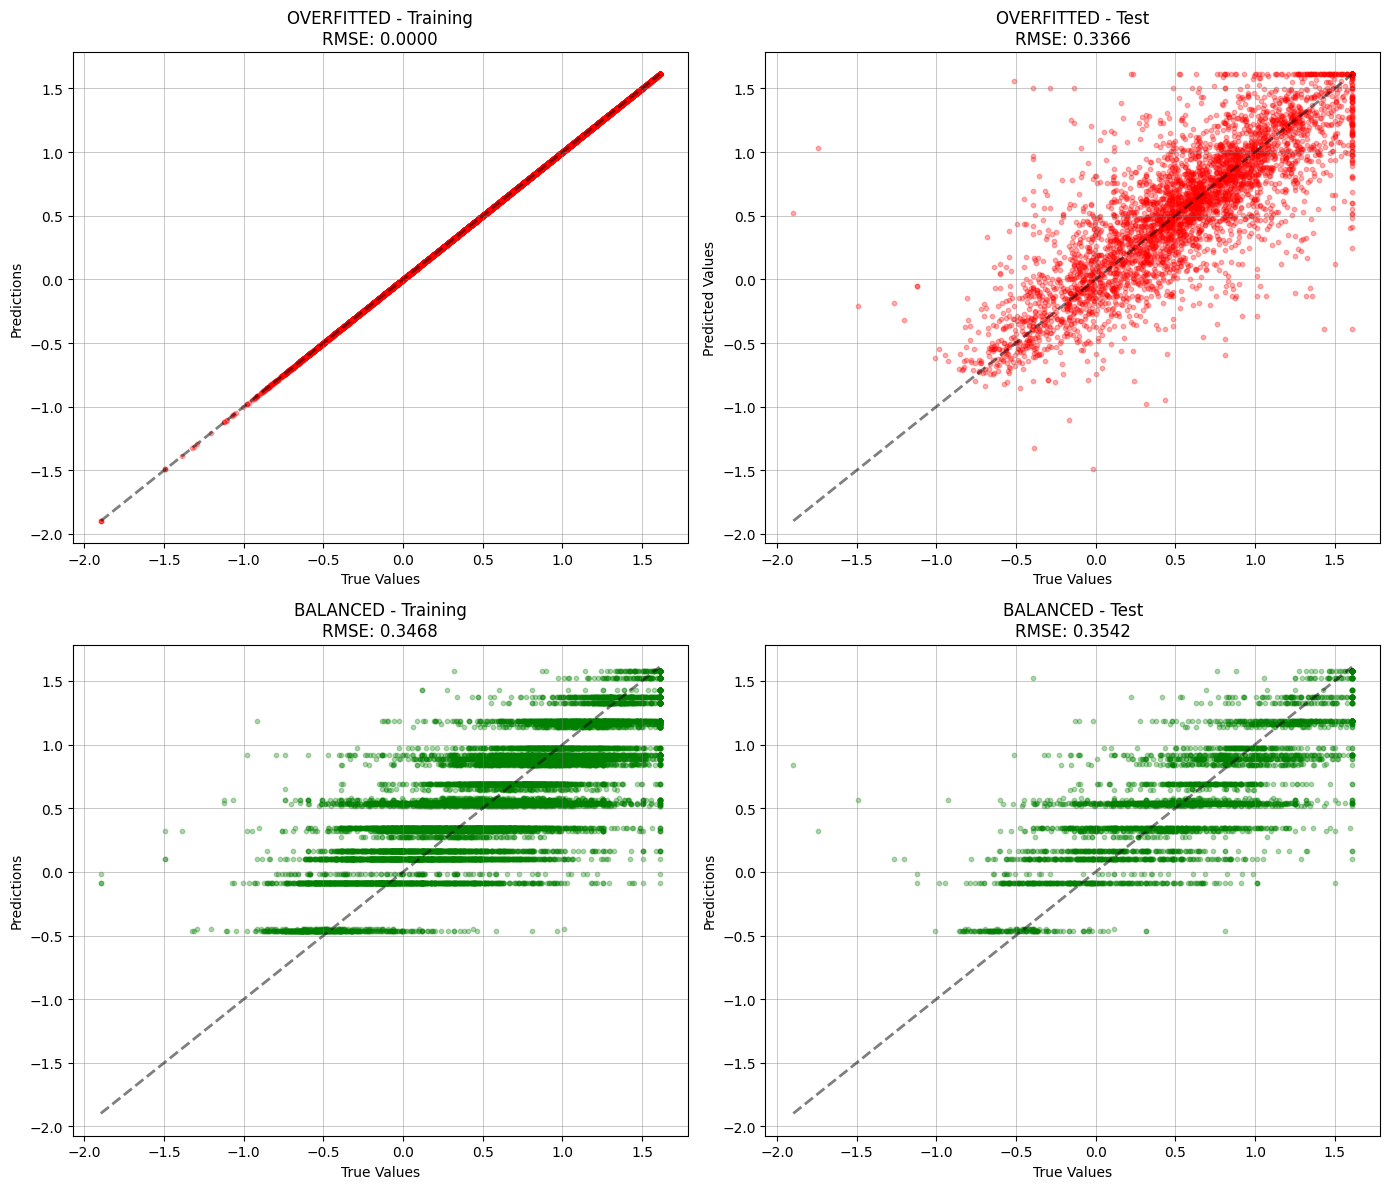

In [ ]:
# Side-by-side comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Overfitted - Training
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.3, s=10, color="red")
axes[0, 0].plot(
	[y_train.min(), y_train.max()],
	[y_train.min(), y_train.max()],
	"k--",
	lw=2,
	alpha=0.5,
)
axes[0, 0].set(
	title=f"OVERFITTED - Training\nRMSE: {train_rmse:.4f}",
	xlabel="True Values",
	ylabel="Predictions",
)
axes[0, 0].grid(True, alpha=0.6, linewidth=0.5, color="grey")

# Overfitted - Test
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.3, s=10, color="red")
axes[0, 1].plot(
	[y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2, alpha=0.5
)
axes[0, 1].set(
	title=f"OVERFITTED - Test\nRMSE: {test_rmse:.4f}",
	xlabel="True Values",
	ylabel="Predictions",
)
axes[0, 1].set_xlabel("True Values")
axes[0, 1].set_ylabel("Predicted Values")
axes[0, 1].grid(True, alpha=0.6, linewidth=0.5, color="grey")

# Balanced - Training
axes[1, 0].scatter(y_train, y_train_pred_bal, alpha=0.3, s=10, color="green")
axes[1, 0].plot(
	[y_train.min(), y_train.max()],
	[y_train.min(), y_train.max()],
	"k--",
	lw=2,
	alpha=0.5,
)
axes[1, 0].set(
	title=f"BALANCED - Training\nRMSE: {train_rmse_bal:.4f}",
	xlabel="True Values",
	ylabel="Predictions",
)
axes[1, 0].grid(True, alpha=0.6, linewidth=0.5, color="grey")

# Balanced - Test
axes[1, 1].scatter(y_test, y_test_pred_bal, alpha=0.3, s=10, color="green")
axes[1, 1].plot(
	[y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2, alpha=0.5
)
axes[1, 1].set(
	title=f"BALANCED - Test\nRMSE: {test_rmse_bal:.4f}",
	xlabel="True Values",
	ylabel="Predictions",
)
axes[1, 1].grid(True, alpha=0.6, linewidth=0.5, color="grey")

plt.tight_layout()
plt.show()

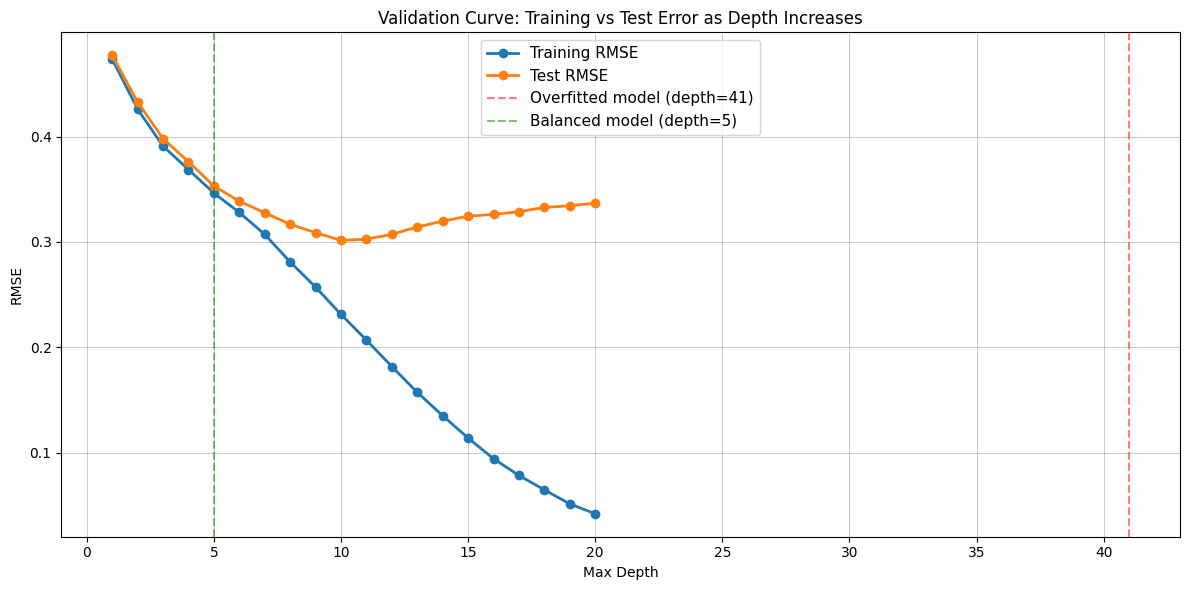

In [13]:
# Test different max_depth values
depths = range(1, 21)
train_scores_list = []
test_scores_list = []

for depth in depths:
	model = DecisionTreeRegressor(max_depth=depth, random_state=42)
	model.fit(X_train, y_train)

	train_pred = model.predict(X_train)
	test_pred = model.predict(X_test)

	train_scores_list.append(RMSE(y_train, train_pred))
	test_scores_list.append(RMSE(y_test, test_pred))

# Plot the validation curve
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
	depths, train_scores_list, "o-", label="Training RMSE", linewidth=2, markersize=6
)
ax.plot(depths, test_scores_list, "o-", label="Test RMSE", linewidth=2, markersize=6)

# Mark the overfitted model's depth
overfitted_depth = dtr_biased.get_depth()
ax.axvline(
	x=overfitted_depth,
	color="red",
	linestyle="--",
	alpha=0.5,
	label=f"Overfitted model (depth={overfitted_depth})",
)

# Mark the balanced model's depth
ax.axvline(
	x=5, color="green", linestyle="--", alpha=0.5, label="Balanced model (depth=5)"
)


ax.set(
	title="Validation Curve: Training vs Test Error as Depth Increases",
	xlabel="Max Depth",
	ylabel="RMSE",
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.6, linewidth=0.5, color="grey")
plt.tight_layout()
plt.show()

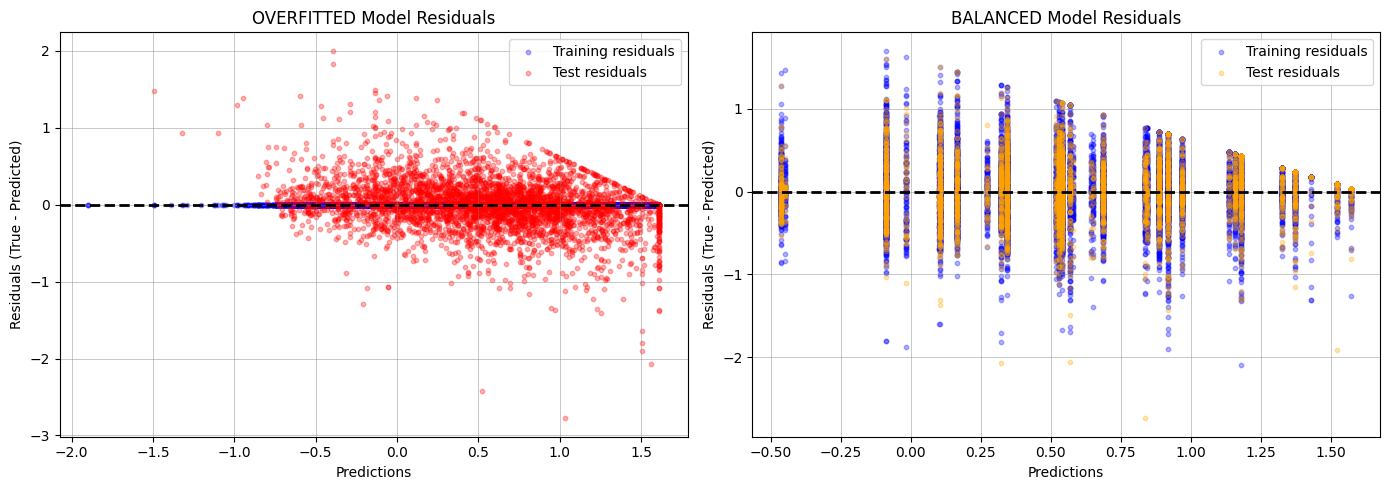

In [ ]:
# Let's visualize residuals (prediction errors) to understand overfitting better
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate residuals
train_residuals_overfitted = y_train - y_train_pred
test_residuals_overfitted = y_test - y_test_pred
train_residuals_balanced = y_train - y_train_pred_bal
test_residuals_balanced = y_test - y_test_pred_bal

# Overfitted model residuals
axes[0].scatter(
	y_train_pred,
	train_residuals_overfitted,
	alpha=0.3,
	s=10,
	label="Training residuals",
	color="blue",
)
axes[0].scatter(
	y_test_pred,
	test_residuals_overfitted,
	alpha=0.3,
	s=10,
	label="Test residuals",
	color="red",
)
axes[0].axhline(y=0, color="black", linestyle="--", linewidth=2)
axes[0].set(
	title="OVERFITTED Model Residuals",
	xlabel="Predictions",
	ylabel="Residuals (True - Predicted)",
)
axes[0].legend()
axes[0].grid(True, alpha=0.6, linewidth=0.5, color="grey")

# Balanced model residuals
axes[1].scatter(
	y_train_pred_bal,
	train_residuals_balanced,
	alpha=0.3,
	s=10,
	label="Training residuals",
	color="blue",
)
axes[1].scatter(
	y_test_pred_bal,
	test_residuals_balanced,
	alpha=0.3,
	s=10,
	label="Test residuals",
	color="orange",
)
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=2)
axes[1].set(
	title="BALANCED Model Residuals",
	xlabel="Predictions",
	ylabel="Residuals (True - Predicted)",
)
axes[1].legend()
axes[1].grid(True, alpha=0.6, linewidth=0.5, color="grey")

plt.tight_layout()
plt.show()

5. **Diagnose the Model**

   * Determine whether the model shows high bias, high variance, or a balanced fit.
   * Justify your reasoning using both the numerical results and theoretical expectations about decision tree behaviour.

> Creating a model with gridsearch now


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

param_grid_tree = {
	"criterion": ["squared_error", "absolute_error"],
	"max_depth": [None, 3, 5, 8, 12, 16],
	"min_samples_split": [2, 5, 10, 20],
	"min_samples_leaf": [1, 2, 5, 10, 20],
	"max_features": [None, "sqrt", "log2"],
}

grid_tree = GridSearchCV(
	estimator=DecisionTreeRegressor(random_state=42),
	param_grid=param_grid_tree,
	cv=3,
	scoring="neg_root_mean_squared_error",
	n_jobs=-1,
	verbose=1,
	refit=True,
	return_train_score=True,
	error_score="raise",
)

grid_tree.fit(X_train_transformed, y_train)
print("Best params:", grid_tree.best_params_)
print("Best CV RMSE:", -grid_tree.best_score_)

Fitting 3 folds for each of 720 candidates, totalling 2160 fits
Best params: {'criterion': 'absolute_error', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best CV RMSE: 0.28756495224981166


In [27]:
# Get the best estimator (already fitted model)
dtr_gt = grid_tree.best_estimator_

# Evaluate the grid search model
y_test_pred_gs = dtr_gt.predict(X_test_transformed)

rmse_gs = RMSE(y_test, y_test_pred_gs)
r2_gs = r2_score(y_test, y_test_pred_gs)

print(f"RMSE: {rmse_gs:.4f}")
print(f"R²: {r2_gs:.4f}")

print("Tree Structure:")
print(f"Depth: {dtr_gt.get_depth()}")
print(f"Leaves: {dtr_gt.get_n_leaves()}")

RMSE: 0.2908
R²: 0.7395
Tree Structure:
Depth: 17
Leaves: 649


### Summary: Overfitting signs


1. Extreme Performance Gap
   - Training RMSE ≈ 0 (nearly perfect)
   - Test RMSE >> Training RMSE (much worse on new data)
   - R² drops significantly from training to test

2. Tree Complexity
   - **`max_depth=None`**: Tree grows without limit (20+ levels deep)
   - **`min_samples_leaf=1`**: Leaves can contain single samples -> memorizes individual points
   - **`min_samples_split=2`**: Splits with minimal data -> creates overly specific rules
   - Result: Thousands of leaves for tiny data subsets

3. **Model Behavior**
   - **Memorizes** training data (including noise and outliers)
   - **Fails to generalize** patterns to new data
   - Creates extremely complex, brittle decision boundaries

#### How the Balanced Model behaves:

- **`max_depth=5`**: Limits complexity, forces broader patterns
- **`min_samples_leaf=50`**: Ensures leaves represent meaningful groups
- **`min_samples_split=100`**: Requires sufficient data before splitting
- Result: Smaller gap between training and test performance

6. **Reflect**

   * Explain how you might adjust tree depth, sample leaf size, or feature preprocessing to correct the identified issue.

### Evaluation

A strong solution should demonstrate:

* Complete, reproducible workflow without hidden variables.
* Quantitative comparison (training vs CV RMSE).
* Analytical reasoning that connects results to the bias–variance framework.
* Evidence of exploration (e.g. trying multiple hyperparameter configurations).

### Stretch Ideas

* Plot a validation curve showing how training and validation RMSE vary with `max_depth`.
* Introduce regularisation via `min_samples_split` and discuss its effect.
* Compare with a Random Forest Regressor to examine ensemble variance reduction.